# 🌍 Global Weather Trend Forecasting
### PM Accelerator - Advanced Tech Assessment

> **PM Accelerator Mission:** By making industry-leading tools and education available to individuals from all backgrounds, we level the playing field for future PM leaders. Our mission is to break down financial barriers, achieve educational fairness, and empower aspiring and experienced PMs to land roles at top-tier companies worldwide.

**Dataset:** World Weather Repository (Kaggle)
**Models:** SARIMA | Facebook Prophet | XGBoost | Ensemble
**Level:** Advanced Assessment


## 0. Install Dependencies

In [22]:
import warnings
warnings.filterwarnings('ignore')
print('All libraries ready!')


All libraries ready!


In [23]:
import sys
!{sys.executable} -m pip install pandas numpy scipy scikit-learn xgboost statsmodels matplotlib seaborn plotly shap
print("Done! Ab Kernel → Restart & Run All karo")

Done! Ab Kernel → Restart & Run All karo


## 1. Imports & Setup

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import shap

plt.rcParams.update({"figure.facecolor": "#f8f8f6", "axes.facecolor": "#ffffff",
    "axes.spines.top": False, "axes.spines.right": False})
COLORS = ["#1a3a5c", "#0e7c5b", "#b84a1e", "#7b4ea0", "#c08000", "#2196F3"]
print("Imports done!")


Imports done!


## 2. Load Dataset

In [25]:
CSV_PATH = "GlobalWeatherRepository.csv"

df_raw = pd.read_csv(CSV_PATH)
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head(3)


Shape: (141703, 41)
Columns: ['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


## 3. Data Cleaning & Preprocessing

In [26]:
df = df_raw.copy()
df["last_updated"] = pd.to_datetime(df["last_updated"])
df = df.sort_values(["country", "location_name", "last_updated"]).reset_index(drop=True)
 
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols     = df.select_dtypes(include="object").columns.tolist()
print(f"Numeric cols: {len(numeric_cols)} | Categorical cols: {len(cat_cols)}")
 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("pct", ascending=False)
print("\nMissing values summary:")
print(missing_df)

Numeric cols: 30 | Categorical cols: 10

Missing values summary:
Empty DataFrame
Columns: [count, pct]
Index: []


In [27]:
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df.groupby("location_name")[col].transform(lambda x: x.fillna(x.median()))
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing after imputation: {df.isnull().sum().sum()}")


Missing after imputation: 0


In [28]:
key_numeric = [c for c in ["temperature_celsius","wind_kph","humidity","pressure_mb"] if c in df.columns]
z_scores = np.abs(stats.zscore(df[key_numeric].fillna(0)))
outlier_mask = (z_scores > 3).any(axis=1)
df_clean = df[~outlier_mask].copy()
print(f"Rows before: {len(df)} | After: {len(df_clean)} | Removed: {outlier_mask.sum()}")


Rows before: 141703 | After: 140357 | Removed: 1346


In [29]:
df_clean["month"]       = df_clean["last_updated"].dt.month
df_clean["day_of_year"] = df_clean["last_updated"].dt.dayofyear
df_clean["week"]        = df_clean["last_updated"].dt.isocalendar().week.astype(int)
df_clean["year"]        = df_clean["last_updated"].dt.year
df_clean["quarter"]     = df_clean["last_updated"].dt.quarter

if "temperature_celsius" in df_clean.columns and "humidity" in df_clean.columns:
    T = df_clean["temperature_celsius"]; H = df_clean["humidity"]
    df_clean["heat_index"] = -8.78 + 1.61*T + 2.34*H - 0.15*T*H

if "precip_mm" in df_clean.columns:
    df_clean["rain_flag"] = (df_clean["precip_mm"] > 0.1).astype(int)

if "latitude" in df_clean.columns:
    df_clean["hemisphere"] = df_clean["latitude"].apply(lambda x: "N" if x >= 0 else "S")

df_clean = df_clean.sort_values(["location_name","last_updated"])
df_clean["temp_7day_avg"] = df_clean.groupby("location_name")["temperature_celsius"].transform(
    lambda x: x.rolling(7, min_periods=1).mean())

print(f"Final shape: {df_clean.shape}")
df_clean.describe().round(2)


Final shape: (140357, 50)


,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,air_quality_gb-defra-index,moon_illumination,month,day_of_year,week,year,quarter,heat_index,rain_flag,temp_7day_avg
count,140357.00,140357.00,1.403570e+05,140357,140357.00,140357.00,140357.00,140357.00,140357.00,140357.00,...,140357.00,140357.00,140357.00,140357.00,140357.00,140357.00,140357.00,140357.00,140357.00,140357.00
mean,18.94,21.83,1.747301e+09,2025-05-15 11:25:02.190842368,21.51,70.72,7.93,12.76,168.70,1014.00,...,2.58,49.85,6.55,184.18,26.61,2024.87,2.52,-21.91,0.16,21.52
min,-41.30,-175.20,1.715849e+09,2024-05-16 01:45:00,-7.60,18.30,2.20,3.60,1.00,984.00,...,1.00,0.00,1.00,1.00,1.00,2024.00,1.00,-187.30,0.00,-6.90
25%,3.75,-6.84,1.731576e+09,2024-11-14 10:15:00,16.10,61.00,3.80,6.10,80.00,1010.00,...,1.00,15.00,4.00,94.00,14.00,2024.00,2.00,-89.40,0.00,16.14
50%,17.12,21.43,1.747300e+09,2025-05-15 12:00:00,24.00,75.20,6.70,10.80,161.00,1013.00,...,2.00,50.00,7.00,184.00,26.00,2025.00,3.00,-31.38,0.00,23.83
75%,40.40,49.88,1.762847e+09,2025-11-11 18:45:00,28.00,82.40,11.00,17.60,255.00,1018.00,...,3.00,85.00,10.00,275.00,40.00,2025.00,4.00,17.83,0.00,27.77
max,64.15,179.22,1.778913e+09,2026-05-16 19:15:00,49.20,120.60,29.30,47.20,360.00,1044.00,...,10.00,100.00,12.00,366.00,52.00,2026.00,4.00,318.95,1.00,47.70
std,24.31,65.82,1.819307e+07,NaN,9.21,16.59,5.05,8.12,103.63,6.77,...,2.43,35.06,3.43,105.01,14.92,0.69,1.11,81.67,0.37,8.98


## 4. Exploratory Data Analysis

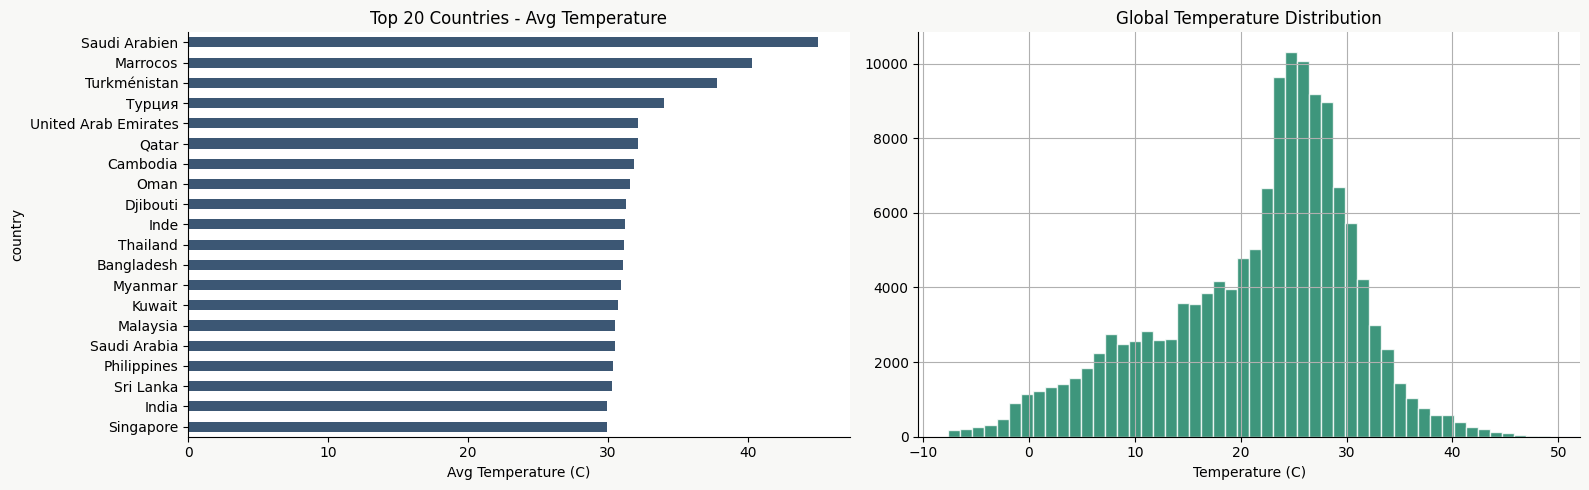

In [30]:
top_countries = df_clean.groupby("country")["temperature_celsius"].mean().nlargest(20)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_countries.sort_values().plot(kind="barh", ax=axes[0], color=COLORS[0], alpha=0.85)
axes[0].set_title("Top 20 Countries - Avg Temperature")
axes[0].set_xlabel("Avg Temperature (C)")
df_clean["temperature_celsius"].hist(bins=50, ax=axes[1], color=COLORS[1], alpha=0.8, edgecolor="white")
axes[1].set_title("Global Temperature Distribution")
axes[1].set_xlabel("Temperature (C)")
plt.tight_layout(); plt.savefig("eda_temperature.png", dpi=150, bbox_inches="tight"); plt.show()


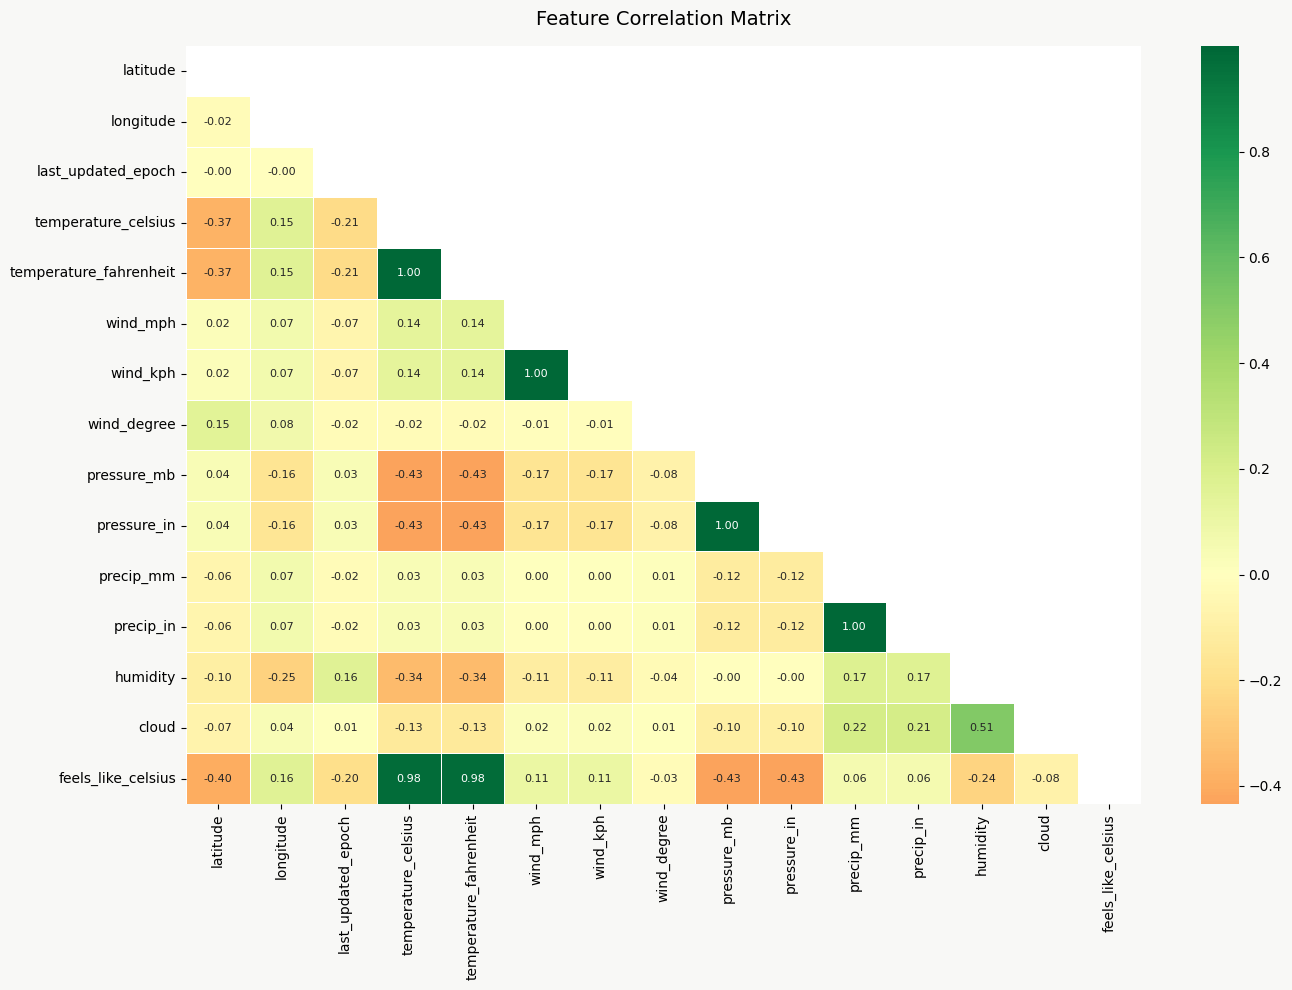

In [31]:
num_feats = [c for c in numeric_cols if c in df_clean.columns][:15]
corr_matrix = df_clean[num_feats].corr()
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5, annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout(); plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight"); plt.show()


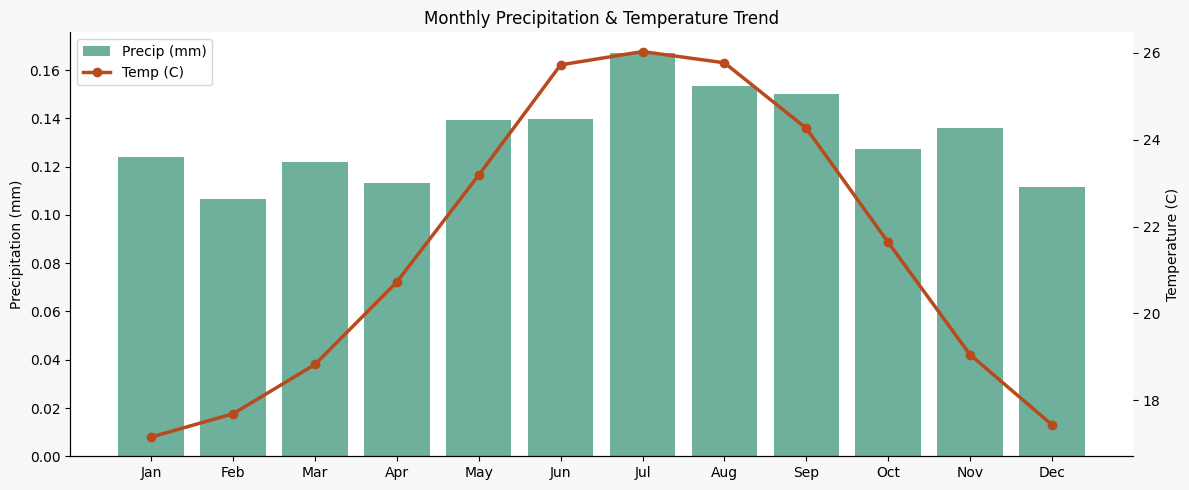

In [32]:
monthly_precip = df_clean.groupby("month")["precip_mm"].mean()
monthly_temp   = df_clean.groupby("month")["temperature_celsius"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(monthly_precip.index, monthly_precip.values, color=COLORS[1], alpha=0.6, label="Precip (mm)")
ax2.plot(monthly_temp.index, monthly_temp.values, color=COLORS[2], lw=2.5, marker="o", label="Temp (C)")
ax1.set_xticks(range(1,13)); ax1.set_xticklabels(month_names)
ax1.set_ylabel("Precipitation (mm)"); ax2.set_ylabel("Temperature (C)")
ax1.set_title("Monthly Precipitation & Temperature Trend")
lines1, labs1 = ax1.get_legend_handles_labels(); lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labs1+labs2, loc="upper left")
plt.tight_layout(); plt.savefig("eda_monthly_trend.png", dpi=150, bbox_inches="tight"); plt.show()


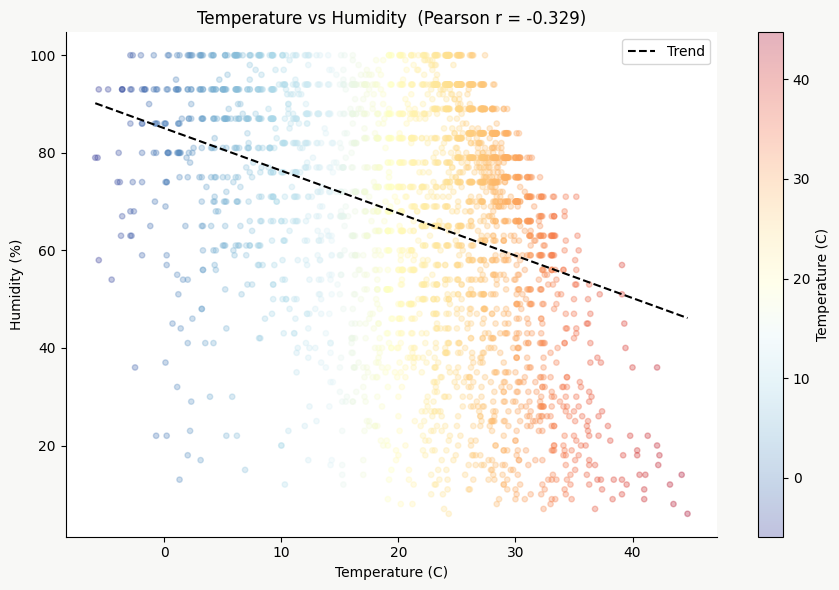

In [33]:
sample = df_clean.sample(min(3000, len(df_clean)), random_state=42)
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(sample["temperature_celsius"], sample["humidity"],
                alpha=0.3, s=15, c=sample["temperature_celsius"], cmap="RdYlBu_r")
plt.colorbar(sc, ax=ax, label="Temperature (C)")
z = np.polyfit(sample["temperature_celsius"].dropna(), sample["humidity"].dropna(), 1)
x_line = np.linspace(sample["temperature_celsius"].min(), sample["temperature_celsius"].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color="black", lw=1.5, ls="--", label="Trend")
r, _ = pearsonr(sample["temperature_celsius"].fillna(0), sample["humidity"].fillna(0))
ax.set_title(f"Temperature vs Humidity  (Pearson r = {r:.3f})")
ax.set_xlabel("Temperature (C)"); ax.set_ylabel("Humidity (%)"); ax.legend()
plt.tight_layout(); plt.savefig("eda_scatter.png", dpi=150, bbox_inches="tight"); plt.show()


## 5. Anomaly Detection

In [34]:
from sklearn.preprocessing import StandardScaler

anomaly_feats = [f for f in ["temperature_celsius", "humidity", "wind_kph",
                              "pressure_mb", "precip_mm", "uv_index"]
                 if f in df_clean.columns]

X_anom   = df_clean[anomaly_feats].fillna(0)
X_scaled = StandardScaler().fit_transform(X_anom)
print("Done:", X_scaled.shape)

Done: (140357, 6)


Anomalies found : 4029
Anomaly rate    : 2.87%


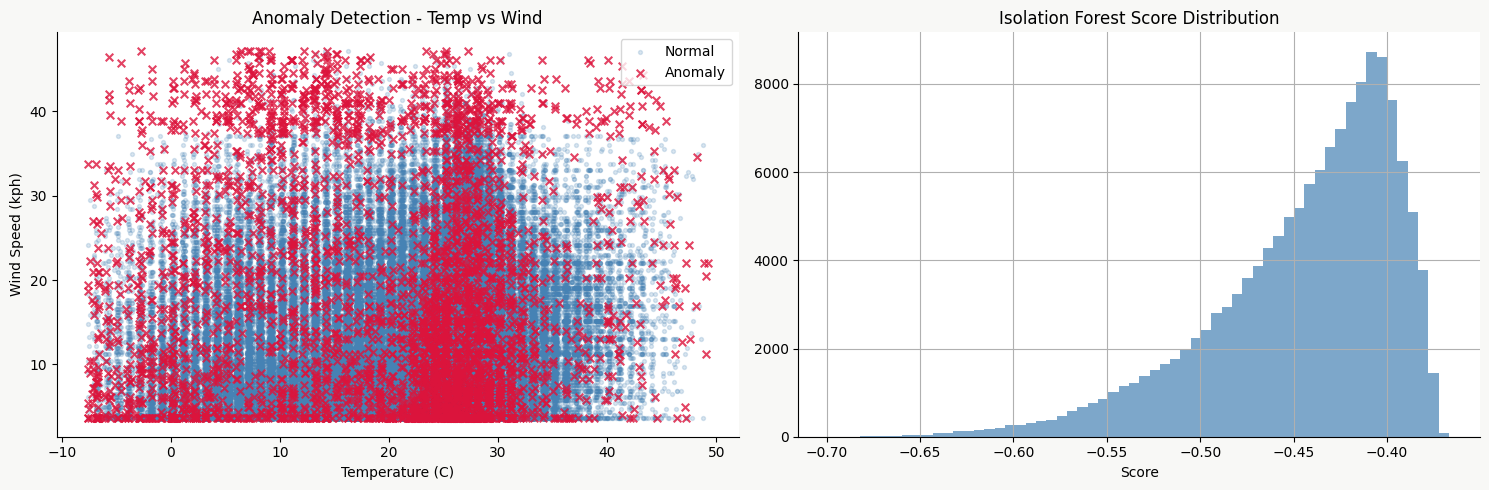

       last_updated  location_name                country  temperature_celsius  humidity  wind_kph  pressure_mb  precip_mm  uv_index
2025-05-29 14:45:00          Dhaka             Bangladesh                 24.8        96      45.7        991.0      21.67       0.2
2026-04-08 06:30:00      Reykjavik                Iceland                  6.0        87      43.2        985.0       3.07       0.0
2025-01-05 10:15:00         Dublin                Ireland                  3.3        87      33.1        987.0       4.18       0.0
2024-09-27 12:00:00      Amsterdam            Netherlands                 12.2        88      31.3        991.0       4.87       3.0
2025-02-19 10:15:00 Vestmannaeyjar                Iceland                  7.1       100      42.1        986.0       2.18       0.0
2024-09-26 10:30:00         Dublin                Ireland                 12.0       100      36.4        984.0       1.57       3.0
2024-12-23 11:45:00      Podgorica             Montenegro            

In [35]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

iforest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df_clean["anomaly_iforest"] = iforest.fit_predict(X_scaled)
df_clean["anomaly_score"]   = iforest.score_samples(X_scaled)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df_clean["anomaly_lof"] = lof.fit_predict(X_scaled)

z_a = np.abs(stats.zscore(X_anom))
df_clean["anomaly_zscore"] = np.where((z_a > 3).any(axis=1), -1, 1)

df_clean["anomaly_votes"] = (
    (df_clean["anomaly_iforest"] == -1).astype(int) +
    (df_clean["anomaly_lof"]     == -1).astype(int) +
    (df_clean["anomaly_zscore"]  == -1).astype(int)
)
df_clean["is_anomaly"] = (df_clean["anomaly_votes"] >= 2).astype(int)

print(f"Anomalies found : {df_clean['is_anomaly'].sum()}")
print(f"Anomaly rate    : {df_clean['is_anomaly'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
normal_d  = df_clean[df_clean["is_anomaly"] == 0]
anomaly_d = df_clean[df_clean["is_anomaly"] == 1]

axes[0].scatter(normal_d["temperature_celsius"], normal_d["wind_kph"],
                alpha=0.2, s=8, c="steelblue", label="Normal")
axes[0].scatter(anomaly_d["temperature_celsius"], anomaly_d["wind_kph"],
                alpha=0.8, s=30, c="crimson", marker="x", lw=1.5, label="Anomaly")
axes[0].set_xlabel("Temperature (C)")
axes[0].set_ylabel("Wind Speed (kph)")
axes[0].set_title("Anomaly Detection - Temp vs Wind")
axes[0].legend()

df_clean["anomaly_score"].hist(bins=60, ax=axes[1], color="steelblue", alpha=0.7)
axes[1].set_title("Isolation Forest Score Distribution")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.savefig("anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()

top_anom = df_clean[df_clean["is_anomaly"]==1].sort_values("anomaly_score").head(10)
print(top_anom[["last_updated","location_name","country"]+anomaly_feats].to_string(index=False))

## 6. SARIMA Forecasting

Time series: 731 days | 2024-05-16 00:00:00 to 2026-05-16 00:00:00
ADF p-value: 0.6880 - Non-stationary


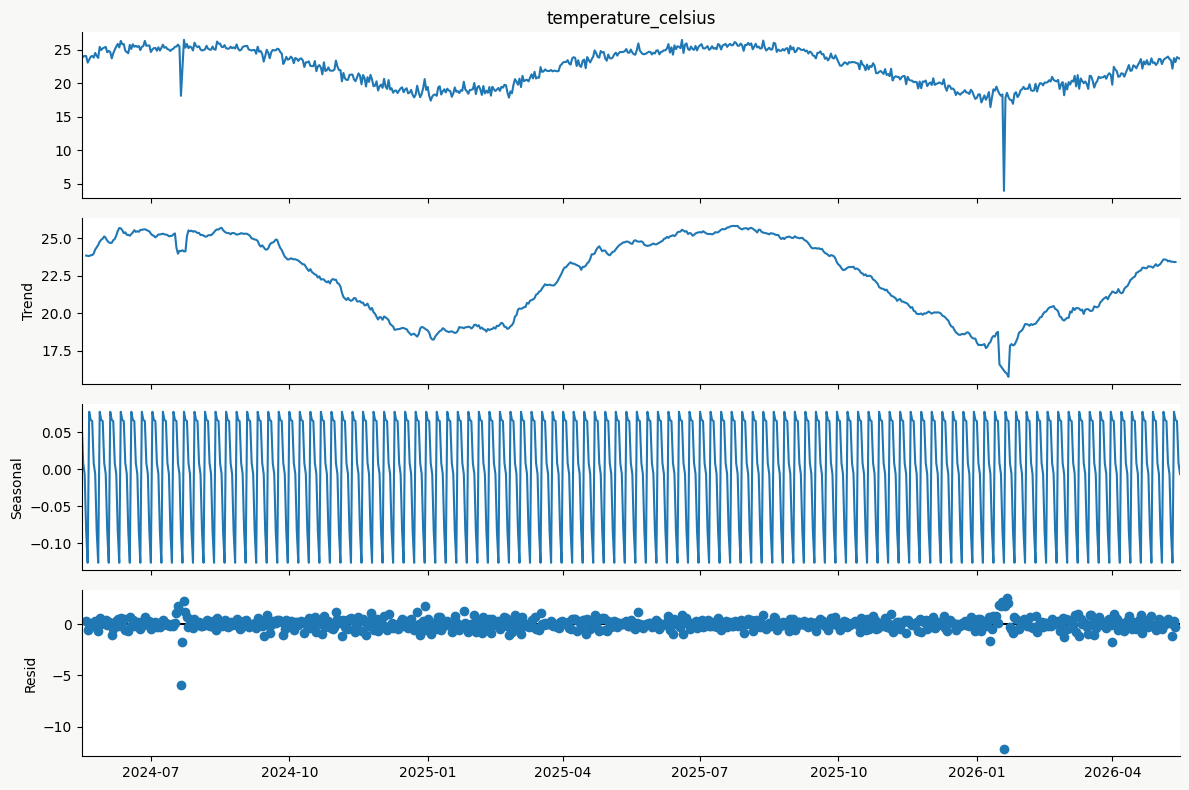

In [36]:
ts_df = (df_clean.groupby("last_updated")["temperature_celsius"]
               .mean().resample("D").mean().interpolate())
print(f"Time series: {len(ts_df)} days | {ts_df.index.min()} to {ts_df.index.max()}")

adf_res = adfuller(ts_df.dropna())
print(f"ADF p-value: {adf_res[1]:.4f} - {'Stationary' if adf_res[1]<0.05 else 'Non-stationary'}")

if len(ts_df) >= 14:
    decomp = seasonal_decompose(ts_df.fillna(method="ffill"), model="additive", period=min(7, len(ts_df)//2))
    fig = decomp.plot(); fig.set_size_inches(12, 8)
    plt.tight_layout(); plt.savefig("seasonal_decompose.png", dpi=150, bbox_inches="tight"); plt.show()


SARIMA: RMSE=6.236 | MAE=5.051 | R2=-6.134


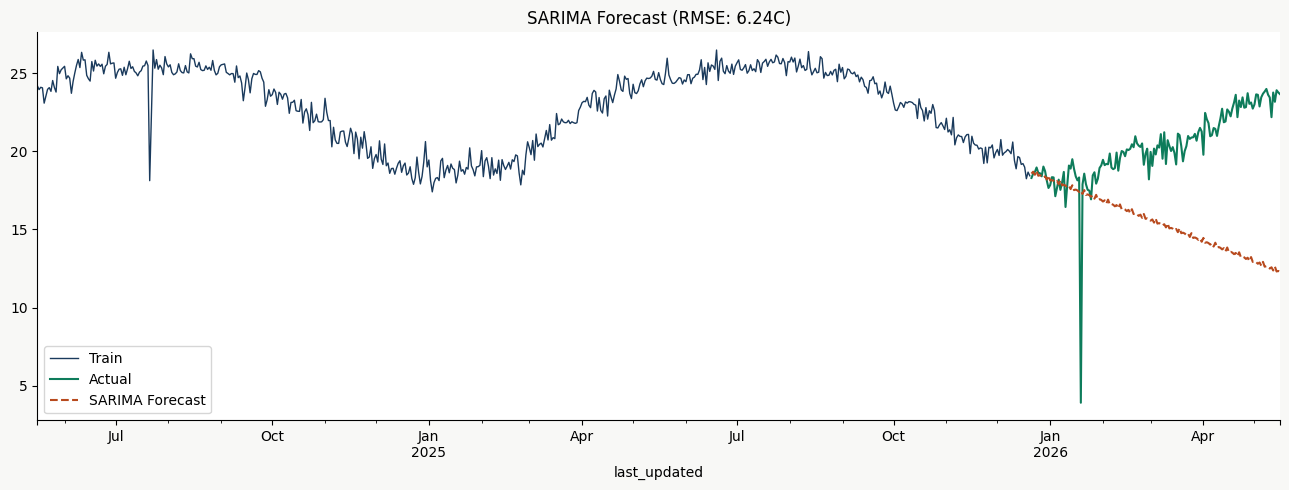

In [37]:
split = int(len(ts_df) * 0.80)
train_ts = ts_df.iloc[:split]; test_ts = ts_df.iloc[split:]

sarima_model = SARIMAX(train_ts, order=(1,1,1), seasonal_order=(1,1,1,7),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

sarima_pred = sarima_fit.forecast(steps=len(test_ts))
sarima_pred.index = test_ts.index

rmse_sarima = np.sqrt(mean_squared_error(test_ts, sarima_pred))
mae_sarima  = mean_absolute_error(test_ts, sarima_pred)
r2_sarima   = r2_score(test_ts, sarima_pred)
print(f"SARIMA: RMSE={rmse_sarima:.3f} | MAE={mae_sarima:.3f} | R2={r2_sarima:.3f}")

fig, ax = plt.subplots(figsize=(13, 5))
train_ts.plot(ax=ax, color=COLORS[0], label="Train", lw=1)
test_ts.plot(ax=ax, color=COLORS[1], label="Actual", lw=1.5)
sarima_pred.plot(ax=ax, color=COLORS[2], ls="--", label="SARIMA Forecast", lw=1.5)
ax.set_title(f"SARIMA Forecast (RMSE: {rmse_sarima:.2f}C)"); ax.legend()
plt.tight_layout(); plt.savefig("sarima_forecast.png", dpi=150, bbox_inches="tight"); plt.show()


## 7. Prophet Forecasting

11:38:20 - cmdstanpy - INFO - Chain [1] start processing
11:38:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet: RMSE=1.727 | MAE=1.100 | R2=0.453


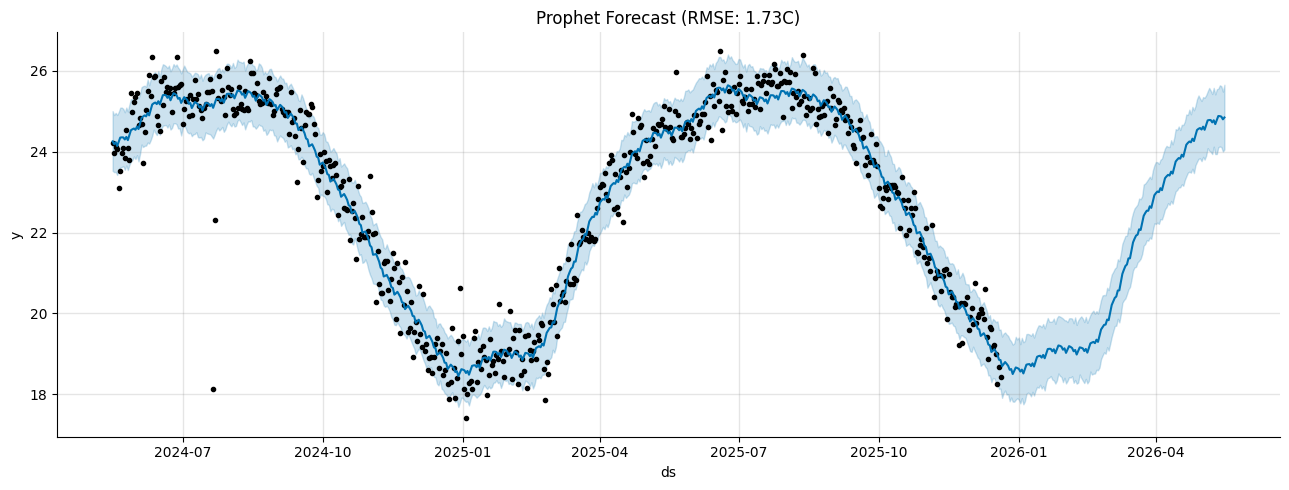

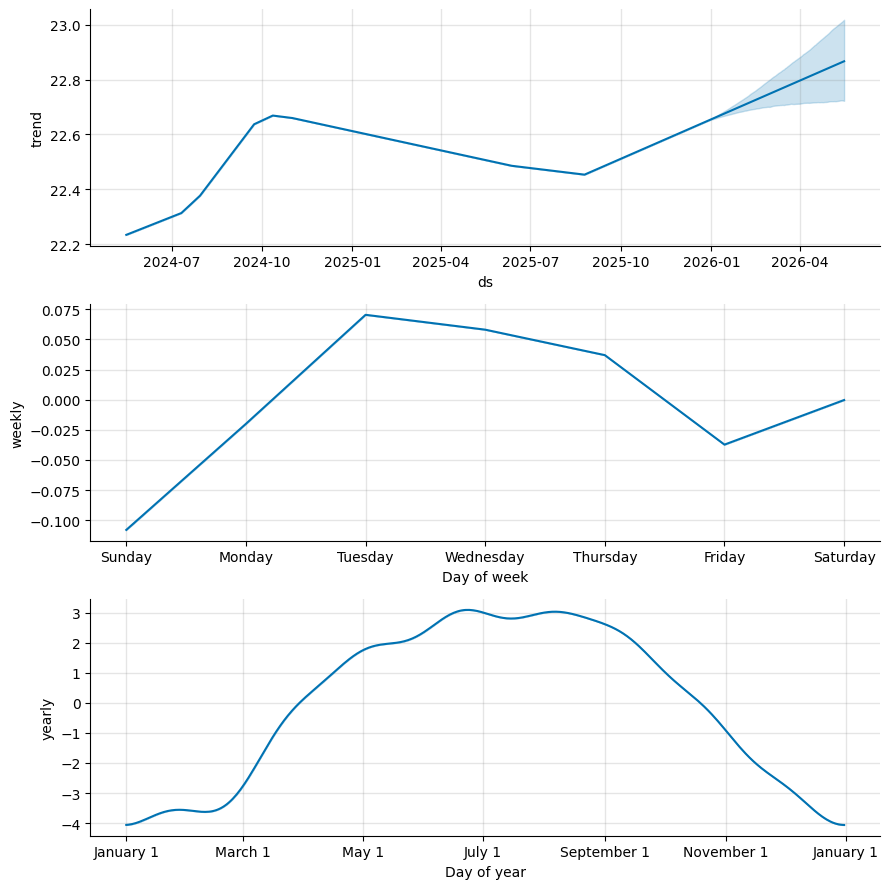

In [38]:
try:
    from prophet import Prophet
    prophet_df = pd.DataFrame({"ds": ts_df.index, "y": ts_df.values})
    split_p = int(len(prophet_df) * 0.80)
    prop_train = prophet_df.iloc[:split_p]; prop_test = prophet_df.iloc[split_p:]

    m = Prophet(seasonality_mode="additive", weekly_seasonality=True,
                yearly_seasonality=True, changepoint_prior_scale=0.1)
    m.fit(prop_train)
    future = m.make_future_dataframe(periods=len(prop_test))
    forecast = m.predict(future)
    prophet_preds = forecast["yhat"].values[split_p:]

    rmse_prophet = np.sqrt(mean_squared_error(prop_test["y"].values, prophet_preds))
    mae_prophet  = mean_absolute_error(prop_test["y"].values, prophet_preds)
    r2_prophet   = r2_score(prop_test["y"].values, prophet_preds)
    print(f"Prophet: RMSE={rmse_prophet:.3f} | MAE={mae_prophet:.3f} | R2={r2_prophet:.3f}")

    fig = m.plot(forecast, figsize=(13, 5))
    plt.title(f"Prophet Forecast (RMSE: {rmse_prophet:.2f}C)")
    plt.tight_layout(); plt.savefig("prophet_forecast.png", dpi=150, bbox_inches="tight"); plt.show()
    fig2 = m.plot_components(forecast); plt.tight_layout()
    plt.savefig("prophet_components.png", dpi=150, bbox_inches="tight"); plt.show()
except ImportError:
    print("Prophet not installed. pip install prophet")
    rmse_prophet, mae_prophet, r2_prophet = None, None, None


## 8. XGBoost Forecasting

In [39]:
TARGET = "temperature_celsius"
ml_features = ["humidity","pressure_mb","wind_kph","uv_index","cloud",
               "precip_mm","visibility_km","feelslike_c","month","day_of_year",
               "week","quarter","heat_index","rain_flag"]
ml_features = [f for f in ml_features if f in df_clean.columns]

for lag in [1, 3, 7]:
    col = f"temp_lag_{lag}"
    df_clean[col] = df_clean.groupby("location_name")[TARGET].shift(lag)
    ml_features.append(col)

df_ml = df_clean[ml_features + [TARGET]].dropna()
X = df_ml[ml_features]; y = df_ml[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {len(ml_features)}")


Train: 111004 | Test: 27752 | Features: 16


[0]	validation_0-rmse:10.27942
[50]	validation_0-rmse:1.38872
[100]	validation_0-rmse:0.87832
[150]	validation_0-rmse:0.74958
[200]	validation_0-rmse:0.66454
[250]	validation_0-rmse:0.60511
[300]	validation_0-rmse:0.56680
[350]	validation_0-rmse:0.53336
[400]	validation_0-rmse:0.50967
[450]	validation_0-rmse:0.48971
[499]	validation_0-rmse:0.47226
XGBoost: RMSE=0.472 | MAE=0.263 | R2=0.998 | MAPE=42000867.6%


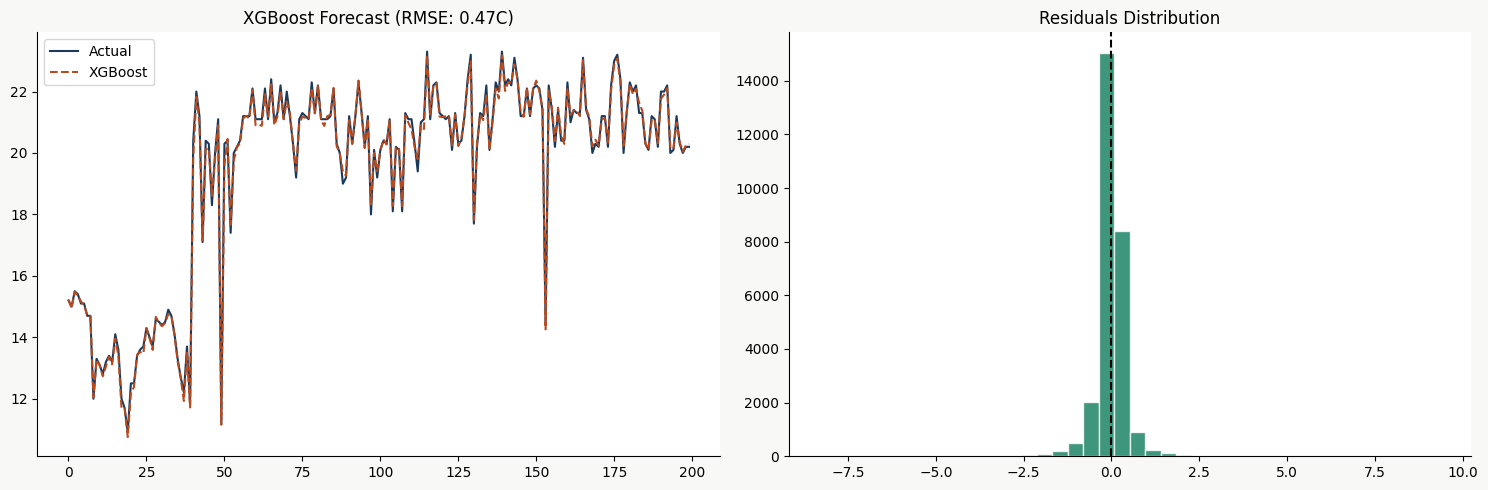

In [40]:
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
    early_stopping_rounds=30, eval_metric="rmse")
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
xgb_pred = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae_xgb  = mean_absolute_error(y_test, xgb_pred)
r2_xgb   = r2_score(y_test, xgb_pred)
mape_xgb = np.mean(np.abs((y_test - xgb_pred) / (y_test + 1e-9))) * 100
print(f"XGBoost: RMSE={rmse_xgb:.3f} | MAE={mae_xgb:.3f} | R2={r2_xgb:.3f} | MAPE={mape_xgb:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
n = min(200, len(y_test))
axes[0].plot(range(n), y_test.values[:n], label="Actual", color=COLORS[0], lw=1.5)
axes[0].plot(range(n), xgb_pred[:n], label="XGBoost", color=COLORS[2], ls="--", lw=1.5)
axes[0].set_title(f"XGBoost Forecast (RMSE: {rmse_xgb:.2f}C)"); axes[0].legend()
residuals = y_test.values - xgb_pred
axes[1].hist(residuals, bins=40, color=COLORS[1], alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="black", ls="--"); axes[1].set_title("Residuals Distribution")
plt.tight_layout(); plt.savefig("xgboost_forecast.png", dpi=150, bbox_inches="tight"); plt.show()


## 9. Ensemble Model

In [41]:
from itertools import product as iproduct

rf_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train); rf_pred = rf_model.predict(X_test)

gb_model = GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
gb_model.fit(X_train, y_train); gb_pred = gb_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred)); r2_rf = r2_score(y_test, rf_pred)
rmse_gb = np.sqrt(mean_squared_error(y_test, gb_pred)); r2_gb = r2_score(y_test, gb_pred)
print(f"RF: RMSE={rmse_rf:.3f} R2={r2_rf:.3f} | GB: RMSE={rmse_gb:.3f} R2={r2_gb:.3f}")

best_rmse, best_w = 999, (0.5, 0.3, 0.2)
for w1, w2 in iproduct(np.arange(0.1, 0.8, 0.1), repeat=2):
    w3 = round(1 - w1 - w2, 2)
    if w3 < 0.05 or w3 > 0.85: continue
    r = np.sqrt(mean_squared_error(y_test, w1*xgb_pred + w2*rf_pred + w3*gb_pred))
    if r < best_rmse: best_rmse = r; best_w = (round(w1,2), round(w2,2), round(w3,2))

ensemble_pred = best_w[0]*xgb_pred + best_w[1]*rf_pred + best_w[2]*gb_pred
rmse_ens = np.sqrt(mean_squared_error(y_test, ensemble_pred))
mae_ens  = mean_absolute_error(y_test, ensemble_pred)
r2_ens   = r2_score(y_test, ensemble_pred)
mape_ens = np.mean(np.abs((y_test - ensemble_pred) / (y_test + 1e-9))) * 100
print(f"Best weights: XGB={best_w[0]}, RF={best_w[1]}, GB={best_w[2]}")
print(f"ENSEMBLE: RMSE={rmse_ens:.3f} | MAE={mae_ens:.3f} | R2={r2_ens:.3f} | MAPE={mape_ens:.1f}%")


RF: RMSE=1.162 R2=0.986 | GB: RMSE=0.579 R2=0.996
Best weights: XGB=0.7, RF=0.1, GB=0.2
ENSEMBLE: RMSE=0.503 | MAE=0.278 | R2=0.997 | MAPE=36606808.2%


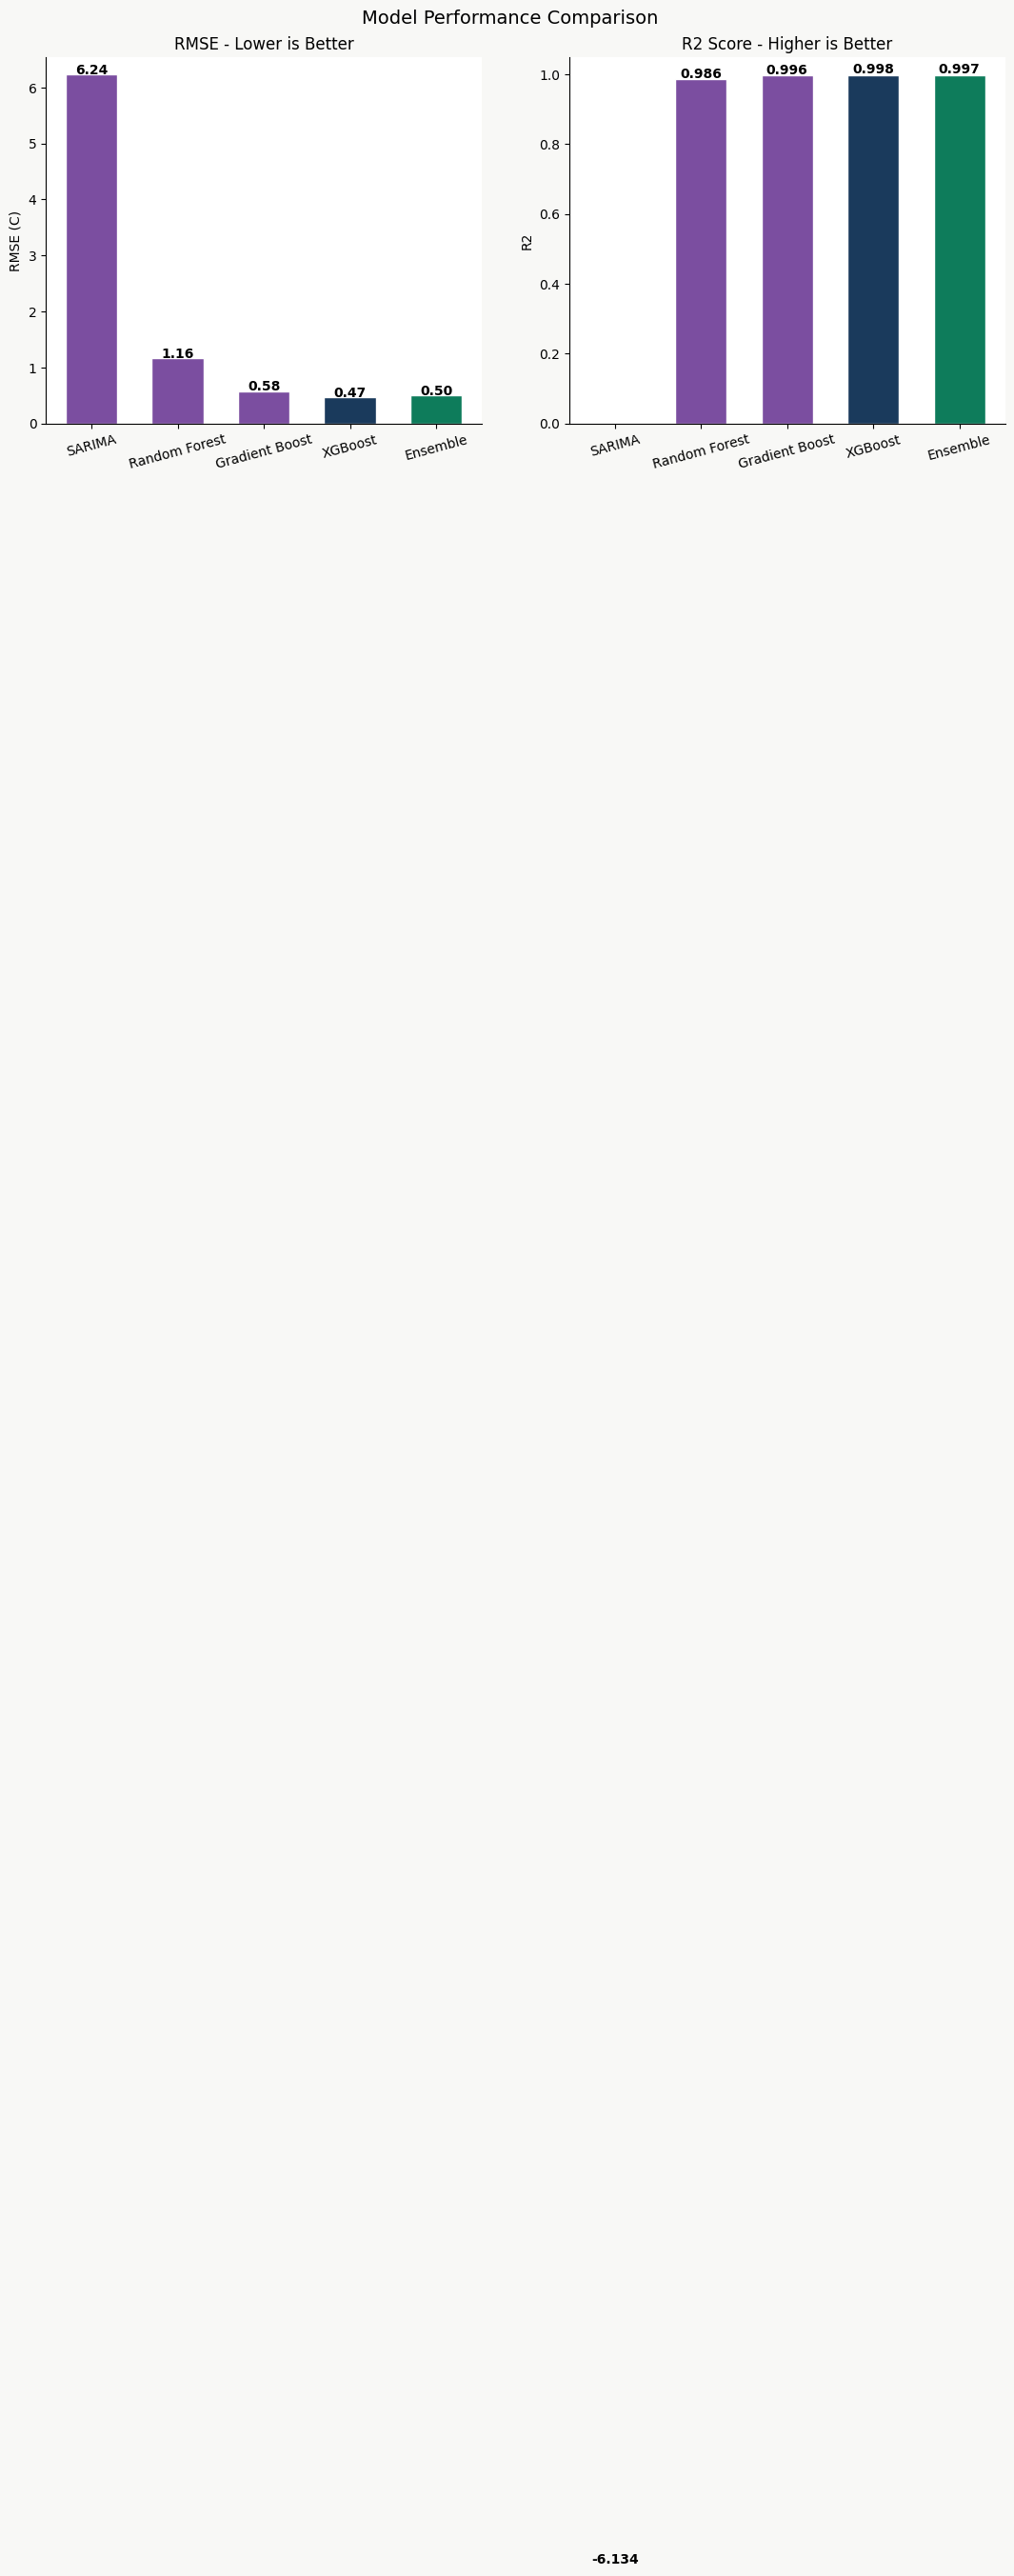

         Model  RMSE     R2
        SARIMA 6.236 -6.134
 Random Forest 1.162  0.986
Gradient Boost 0.579  0.996
       XGBoost 0.472  0.998
      Ensemble 0.503  0.997


In [52]:
model_names = ["SARIMA", "Random Forest", "Gradient Boost", "XGBoost", "Ensemble"]
rmses = [rmse_sarima, rmse_rf, rmse_gb, rmse_xgb, rmse_ens]
r2s   = [r2_sarima,   r2_rf,   r2_gb,   r2_xgb,   r2_ens]
bar_colors = [COLORS[3], COLORS[3], COLORS[3], COLORS[0], COLORS[1]]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
bars = axes[0].bar(model_names, rmses, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("RMSE - Lower is Better")
axes[0].set_ylabel("RMSE (C)")
axes[0].tick_params(axis="x", rotation=15)
 
bars2 = axes[1].bar(model_names, r2s, color=bar_colors, edgecolor="white", width=0.6)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("R2 Score - Higher is Better")
axes[1].set_ylabel("R2")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=15)
 
plt.suptitle("Model Performance Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 
results = pd.DataFrame({
    "Model": model_names,
    "RMSE":  [round(r, 3) for r in rmses],
    "R2":    [round(r, 3) for r in r2s]
})
print(results.to_string(index=False))

## 10. Feature Importance & SHAP

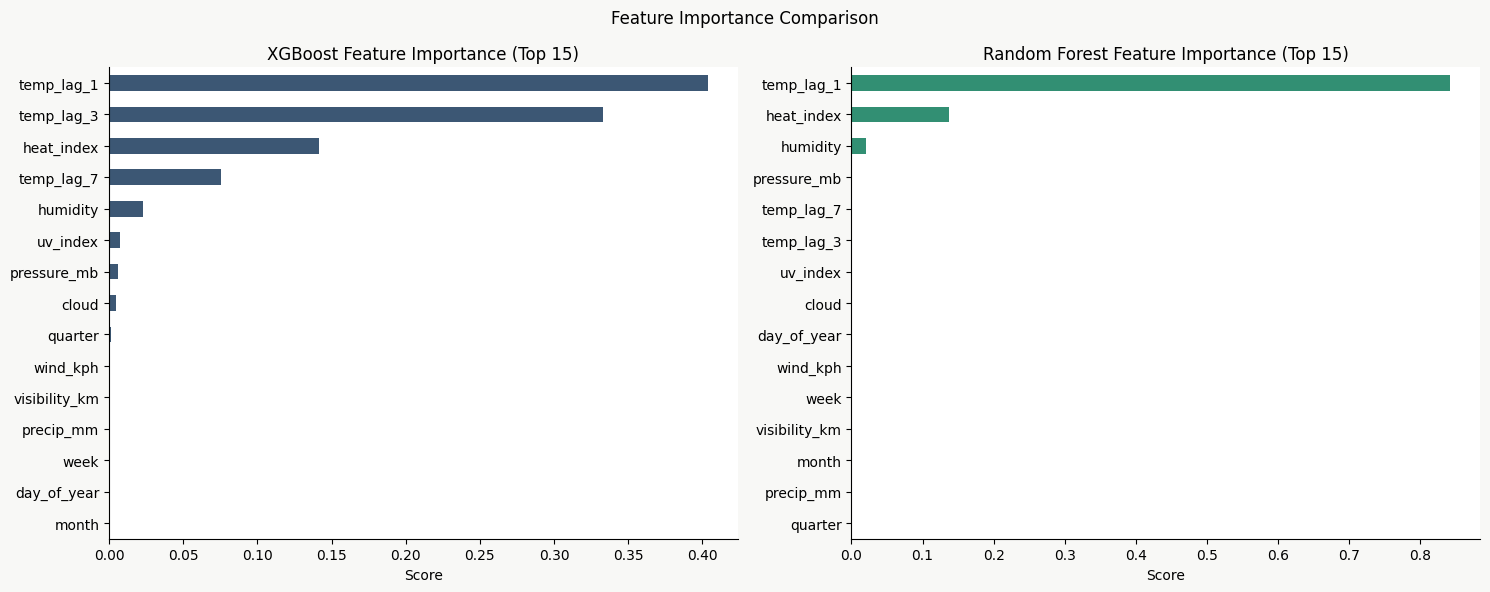

In [43]:
xgb_imp = pd.Series(xgb_model.feature_importances_, index=ml_features).sort_values()
rf_imp  = pd.Series(rf_model.feature_importances_,  index=ml_features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
xgb_imp.tail(15).plot(kind="barh", ax=axes[0], color=COLORS[0], alpha=0.85)
axes[0].set_title("XGBoost Feature Importance (Top 15)"); axes[0].set_xlabel("Score")
rf_imp.tail(15).plot(kind="barh", ax=axes[1], color=COLORS[1], alpha=0.85)
axes[1].set_title("Random Forest Feature Importance (Top 15)"); axes[1].set_xlabel("Score")
plt.suptitle("Feature Importance Comparison"); plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight"); plt.show()


In [54]:
try:
    explainer = shap.TreeExplainer(xgb_model)
    X_sample  = X_test.sample(min(500, len(X_test)), random_state=42)
    shap_vals = explainer.shap_values(X_sample)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, X_sample, plot_type="bar", show=False, max_display=15)
    plt.title("SHAP Feature Importance"); plt.tight_layout()
    plt.savefig("shap_importance.png", dpi=150, bbox_inches="tight"); plt.show()

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, X_sample, show=False, max_display=15)
    plt.title("SHAP Summary - Direction of Effect"); plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight"); plt.show()
    print("SHAP analysis complete!")
except Exception as e:
    print(f"SHAP error: {e}")


SHAP error: could not convert string to float: '[2.2435047E1]'


## 11. Climate Analysis

In [55]:
if "latitude" in df_clean.columns:
    city_prof = df_clean.groupby("location_name").agg(
        avg_temp=("temperature_celsius","mean"), avg_humid=("humidity","mean"),
        avg_precip=("precip_mm","mean"), avg_wind=("wind_kph","mean"),
        latitude=("latitude","first"), country=("country","first")).dropna()

    X_clust = StandardScaler().fit_transform(
        city_prof[["avg_temp","avg_humid","avg_precip","avg_wind","latitude"]])
    city_prof["cluster"] = KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_clust)

    rank_names = {0:"Polar",1:"Continental",2:"Mediterranean",3:"Tropical",4:"Desert"}
    temps_rank = city_prof.groupby("cluster")["avg_temp"].mean().rank().astype(int) - 1
    city_prof["climate_zone"] = city_prof["cluster"].map({k: rank_names[temps_rank[k]] for k in temps_rank.index})

    print(city_prof.groupby("climate_zone")[["avg_temp","avg_humid","avg_precip"]].mean().round(2))


               avg_temp  avg_humid  avg_precip
climate_zone                                  
Continental       23.46      75.03        0.17
Desert            27.72      38.96        0.04
Mediterranean     25.50      90.00        1.70
Polar             13.26      68.15        0.09
Tropical          26.54      75.15        0.17


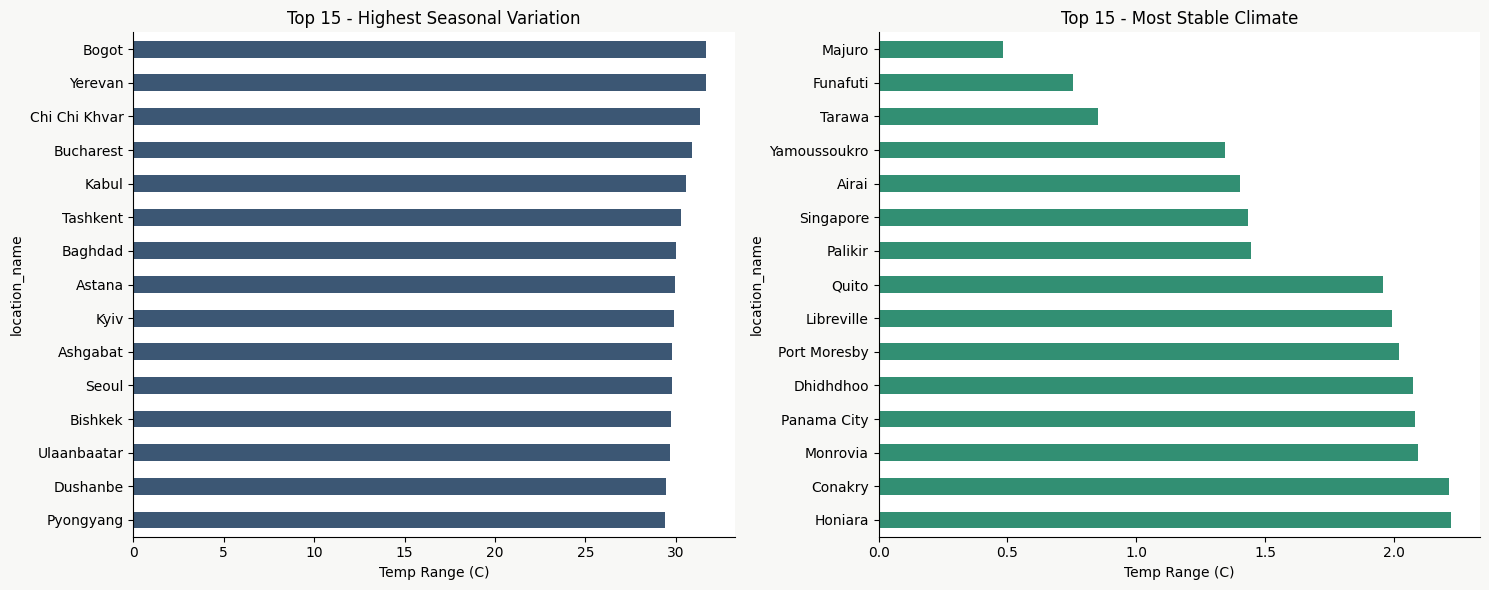

Total cities analyzed: 207

Highest variation:
location_name
Bogot            31.669492
Yerevan          31.660992
Chi Chi Khvar    31.336886
Bucharest        30.907180
Kabul            30.552760
dtype: float64

Lowest variation:
location_name
Majuro          0.483686
Funafuti        0.755383
Tarawa          0.850051
Yamoussoukro    1.344886
Airai           1.404147
dtype: float64


In [57]:
city_seasonal = df_clean.groupby(["location_name", "month"])["temperature_celsius"].mean().unstack()

# Sirf unhe rakho jinka kam se kam 6 months ka data ho
city_seasonal = city_seasonal[city_seasonal.count(axis=1) >= 6]

city_amp = (city_seasonal.max(axis=1) - city_seasonal.min(axis=1)).dropna()

# Positive values hi rakho
city_amp = city_amp[city_amp > 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

city_amp.nlargest(15).sort_values().plot(
    kind="barh", ax=axes[0], color=COLORS[0], alpha=0.85)
axes[0].set_title("Top 15 - Highest Seasonal Variation")
axes[0].set_xlabel("Temp Range (C)")

city_amp.nsmallest(15).sort_values(ascending=False).plot(
    kind="barh", ax=axes[1], color=COLORS[1], alpha=0.85)
axes[1].set_title("Top 15 - Most Stable Climate")
axes[1].set_xlabel("Temp Range (C)")

plt.tight_layout()
plt.savefig("climate_seasonal.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total cities analyzed: {len(city_amp)}")
print(f"\nHighest variation:\n{city_amp.nlargest(5)}")
print(f"\nLowest variation:\n{city_amp.nsmallest(5)}")

## 12. Air Quality Analysis

Using column: air_quality_PM2.5


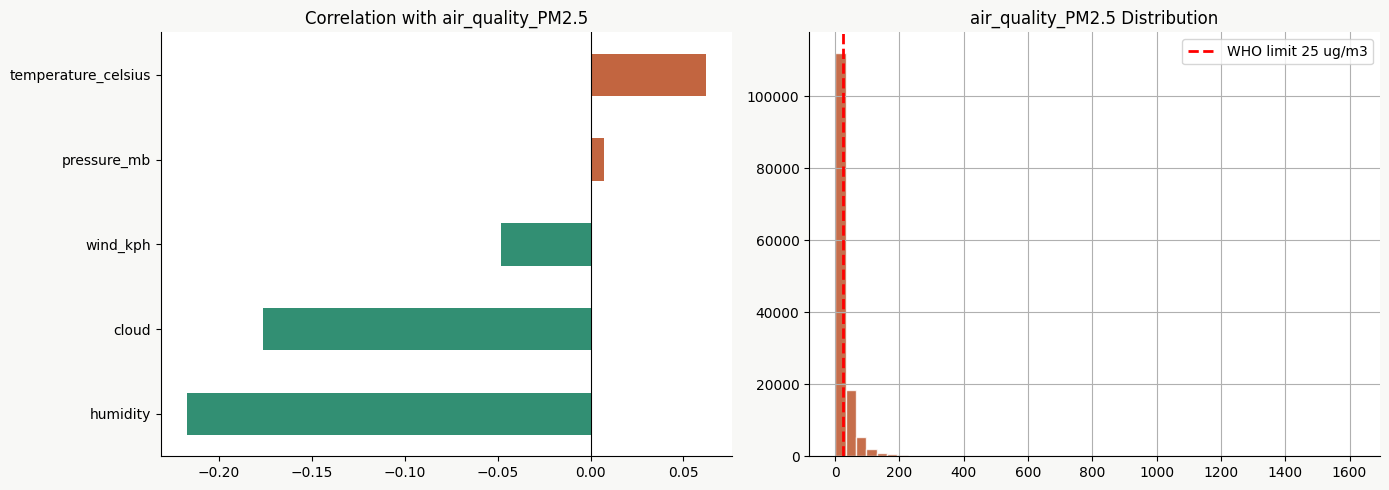

Worst cities by PM2.5:
location_name
Kuwait              176.7
Santiago            145.9
Jakarta             143.5
Riyadh              136.5
Beijing             130.4
New Delhi           110.1
Ho Chi Minh City    104.6
Kuwait City          91.1
Hanoi                76.7
Dhaka                70.3
Name: air_quality_PM2.5, dtype: float64


In [58]:
pm_col = next((c for c in df_clean.columns if "pm2" in c.lower() or ("air" in c.lower() and "2" in c)), None)
if pm_col:
    print(f"Using column: {pm_col}")
    weather_feats = [f for f in ["temperature_celsius","wind_kph","humidity","pressure_mb","cloud"] if f in df_clean.columns]
    corr_aq = {}
    for feat in weather_feats:
        valid = df_clean[[feat, pm_col]].dropna()
        if len(valid) > 30:
            r, _ = pearsonr(valid[feat], valid[pm_col]); corr_aq[feat] = r

    corr_s = pd.Series(corr_aq).sort_values()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_bar = ["#b84a1e" if v > 0 else "#0e7c5b" for v in corr_s.values]
    corr_s.plot(kind="barh", ax=axes[0], color=colors_bar, alpha=0.85)
    axes[0].axvline(0, color="black", lw=0.8); axes[0].set_title(f"Correlation with {pm_col}")
    df_clean[pm_col].hist(bins=50, ax=axes[1], color=COLORS[2], alpha=0.8, edgecolor="white")
    axes[1].axvline(25, color="red", lw=2, ls="--", label="WHO limit 25 ug/m3")
    axes[1].set_title(f"{pm_col} Distribution"); axes[1].legend()
    plt.tight_layout(); plt.savefig("air_quality.png", dpi=150, bbox_inches="tight"); plt.show()

    print("Worst cities by PM2.5:")
    print(df_clean.groupby("location_name")[pm_col].mean().nlargest(10).round(1))
else:
    print("PM2.5 column not found. Columns:", [c for c in df_clean.columns if "air" in c.lower()])


## 13. Spatial Analysis

In [59]:
if "latitude" in df_clean.columns and "longitude" in df_clean.columns:
    city_map = df_clean.groupby("location_name").agg(
        avg_temp=("temperature_celsius","mean"), avg_precip=("precip_mm","mean"),
        lat=("latitude","first"), lon=("longitude","first"), country=("country","first")
    ).dropna().reset_index()

    fig = px.scatter_geo(city_map, lat="lat", lon="lon", color="avg_temp",
        size=city_map["avg_precip"].clip(0,200)+5, hover_name="location_name",
        hover_data={"country":True, "avg_temp":":.1f", "avg_precip":":.1f"},
        color_continuous_scale="RdYlBu_r", projection="natural earth",
        title="Global Weather Map - Temperature (color) & Precipitation (size)")
    fig.update_layout(height=550)
    fig.write_html("spatial_map.html")
    fig.show()
    print("Saved: spatial_map.html")


Saved: spatial_map.html


          avg_temp  avg_humid  avg_precip
lat_band                                 
90S-60S        NaN        NaN         NaN
60S-30S      14.05      77.28        0.10
30S-0        24.05      68.88        0.17
0-30N        26.38      69.10        0.17
30N-60N      15.96      61.95        0.08
60N-90N       7.91      76.39        0.11


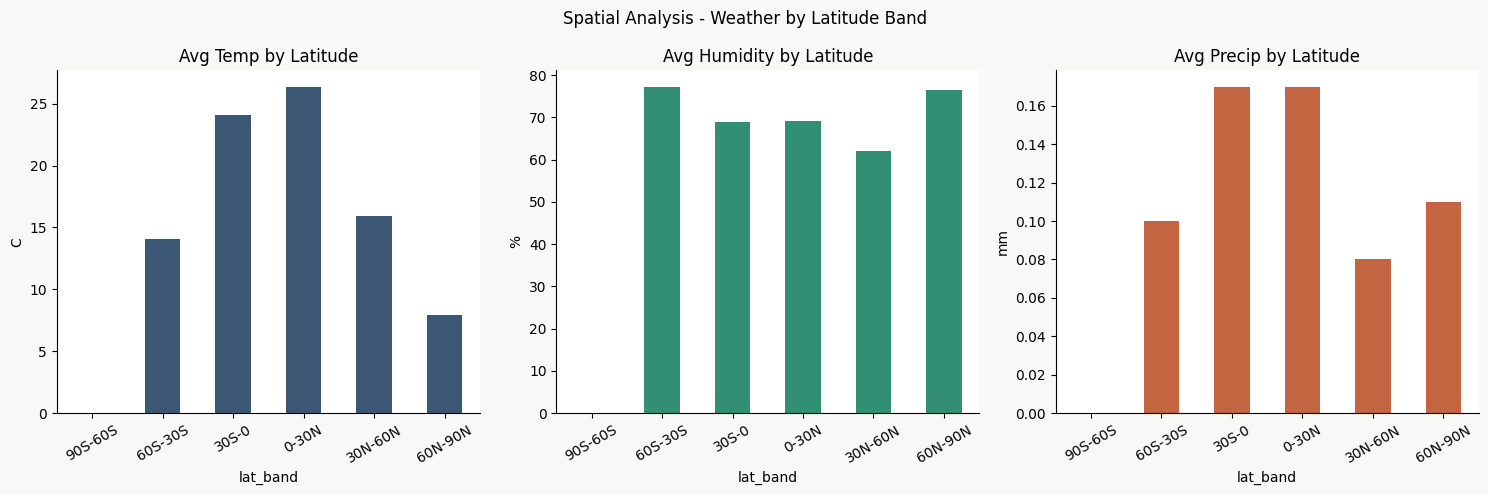

In [60]:
if "latitude" in df_clean.columns:
    bins   = [-90,-60,-30,0,30,60,90]
    labels = ["90S-60S","60S-30S","30S-0","0-30N","30N-60N","60N-90N"]
    df_clean["lat_band"] = pd.cut(df_clean["latitude"], bins=bins, labels=labels)
    lat_stats = df_clean.groupby("lat_band").agg(
        avg_temp=("temperature_celsius","mean"), avg_humid=("humidity","mean"),
        avg_precip=("precip_mm","mean")).round(2)
    print(lat_stats)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    lat_stats["avg_temp"].plot(kind="bar", ax=axes[0], color=COLORS[0], rot=30, alpha=0.85)
    axes[0].set_title("Avg Temp by Latitude"); axes[0].set_ylabel("C")
    lat_stats["avg_humid"].plot(kind="bar", ax=axes[1], color=COLORS[1], rot=30, alpha=0.85)
    axes[1].set_title("Avg Humidity by Latitude"); axes[1].set_ylabel("%")
    lat_stats["avg_precip"].plot(kind="bar", ax=axes[2], color=COLORS[2], rot=30, alpha=0.85)
    axes[2].set_title("Avg Precip by Latitude"); axes[2].set_ylabel("mm")
    plt.suptitle("Spatial Analysis - Weather by Latitude Band"); plt.tight_layout()
    plt.savefig("spatial_latitude.png", dpi=150, bbox_inches="tight"); plt.show()


## 14. Final Summary

In [61]:
print("=" * 60)
print("  GLOBAL WEATHER FORECASTING - FINAL RESULTS")
print("=" * 60)
print(f"  SARIMA     : RMSE={rmse_sarima:.3f}  R2={r2_sarima:.3f}")
print(f"  Rand Forest: RMSE={rmse_rf:.3f}  R2={r2_rf:.3f}")
print(f"  Grad Boost : RMSE={rmse_gb:.3f}  R2={r2_gb:.3f}")
print(f"  XGBoost    : RMSE={rmse_xgb:.3f}  R2={r2_xgb:.3f}  MAPE={mape_xgb:.1f}%")
print(f"  ENSEMBLE   : RMSE={rmse_ens:.3f}  R2={r2_ens:.3f}  MAPE={mape_ens:.1f}%  <-- BEST")
print("")
print(f"  Anomalies detected: {df_clean['is_anomaly'].sum()} ({df_clean['is_anomaly'].mean()*100:.2f}%)")
print("  Methods: Isolation Forest + LOF + Z-score (consensus)")
print("")
print("  Top 5 Features (XGBoost):")
top5 = pd.Series(xgb_model.feature_importances_, index=ml_features).nlargest(5)
for feat, imp in top5.items():
    print(f"    {feat:25s}  {imp:.4f}")
print("")
print("  Files saved:")
for f in ["eda_temperature.png","eda_correlation.png","eda_monthly_trend.png",
          "eda_scatter.png","anomaly_detection.png","seasonal_decompose.png",
          "sarima_forecast.png","prophet_forecast.png","xgboost_forecast.png",
          "model_comparison.png","climate_seasonal.png","air_quality.png",
          "feature_importance.png","shap_importance.png","spatial_map.html","spatial_latitude.png"]:
    print(f"    {f}")
print("")
print("  PM Accelerator - Leveling the playing field for PM leaders")
print("  https://www.pmaccelerator.io")
print("=" * 60)


  GLOBAL WEATHER FORECASTING - FINAL RESULTS
  SARIMA     : RMSE=6.236  R2=-6.134
  Rand Forest: RMSE=1.162  R2=0.986
  Grad Boost : RMSE=0.579  R2=0.996
  XGBoost    : RMSE=0.472  R2=0.998  MAPE=42000867.6%
  ENSEMBLE   : RMSE=0.503  R2=0.997  MAPE=36606808.2%  <-- BEST

  Anomalies detected: 4029 (2.87%)
  Methods: Isolation Forest + LOF + Z-score (consensus)

  Top 5 Features (XGBoost):
    temp_lag_1                 0.4035
    temp_lag_3                 0.3331
    heat_index                 0.1413
    temp_lag_7                 0.0753
    humidity                   0.0227

  Files saved:
    eda_temperature.png
    eda_correlation.png
    eda_monthly_trend.png
    eda_scatter.png
    anomaly_detection.png
    seasonal_decompose.png
    sarima_forecast.png
    prophet_forecast.png
    xgboost_forecast.png
    model_comparison.png
    climate_seasonal.png
    air_quality.png
    feature_importance.png
    shap_importance.png
    spatial_map.html
    spatial_latitude.png

  PM Acceler